## Random walk model

A model for analyzing a time series, which is the sum of a deterministic *trend* series and a stationary *noise* series, is the so called **[random walk](https://en.wikipedia.org/wiki/Random_walk) with drift model**, given by

$$y_t = \delta+y_{t-1}+w_t,$$

for $t = 1, 2,...$, with initial condition $y_0 = 0$, where $w_t$ is white noise.

For **random walk with drift model**, the equation from above may be rewritten as

$$y_t = \delta t + \sum_{j=1}^t w_j\text{,}$$

for $t = 1,2,...$.

The constant $\delta$ is called the drift, and if $\delta = 0$, then it is simply called *random walk*. If $\delta = 0$, the value of the time series at time $t$ is equal to the value of the series at time $t-1$ plus a completely random movement determined by $w_t$. 

$$\Delta y_t = y_t-y_{t-1} = w_t$$

The $w_{t}$ values can be interpreted as independent “shocks” which perturb the current state $y_t$ in the amount of $w_{t}$ to produce a new state $y_{t+1}$.

The graph below shows a random walk and a random walk with drift generated with Python:

In [1]:
%load_ext lab_black

In [16]:
# Importing necessary libraries
import random
import matplotlib.pyplot as plt
import numpy as np

The time series of a *Random Walk*, the expected value of the steps is zero as it is determined by white noise, meaning the walk should not trend in any particular direction over time. However for a *Random Walk With Drift*, you have a non-zero mean in the step size, indicating a tendency to move in a specific direction over time. These trends can be seen in the plots of the time series below.

The The distribution of white noise can be created in many ways. including use the normal distribution or +/-1 coin flips, it just needs to have a mean of 0 and be independent.

#### Using Normal Distributed Shocks

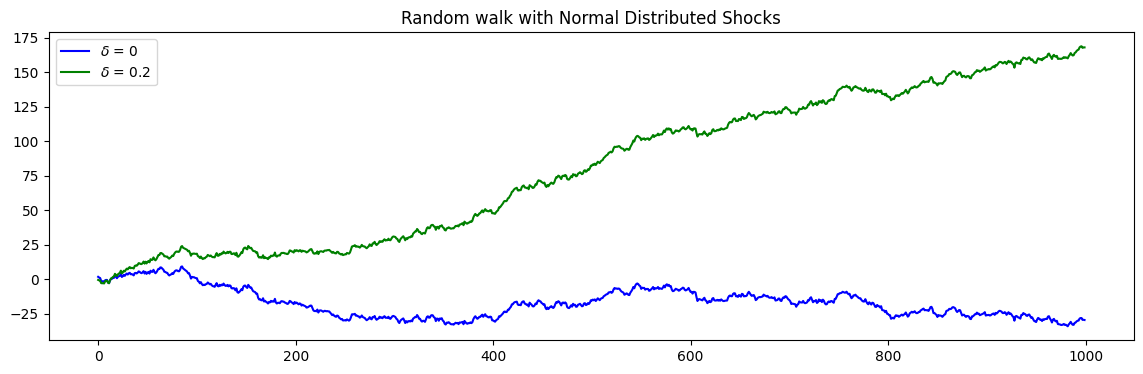

In [45]:
# Seed random number generator
np.random.seed(1)

# Create random walk series and random walk with drift series
random_walk = list()
random_walk_d = list()
random_walk.append(np.random.normal(0,1))
random_walk_d.append(np.random.normal(0,1))

for i in range(1, 1000):
    # Random walk
    movement = np.random.normal(0, 1, 1000)
    value = random_walk[i - 1] + movement[i - 1]
    random_walk.append(value)

    # Random walk with drift
    movement_d = movement[i - 1] + 0.2
    value_d = random_walk_d[i - 1] + movement_d
    random_walk_d.append(value_d)


# Plot both the random walk series
plt.figure(figsize=(14, 4))
plt.plot(random_walk, color="blue", label="$\u03B4$ = 0")
plt.plot(random_walk_d, color="green", label="$\u03B4$ = 0.2")

plt.title("Random walk with Normal Distributed Shocks")
plt.legend()
plt.show()

#### Using ±1 coin-flip shocks

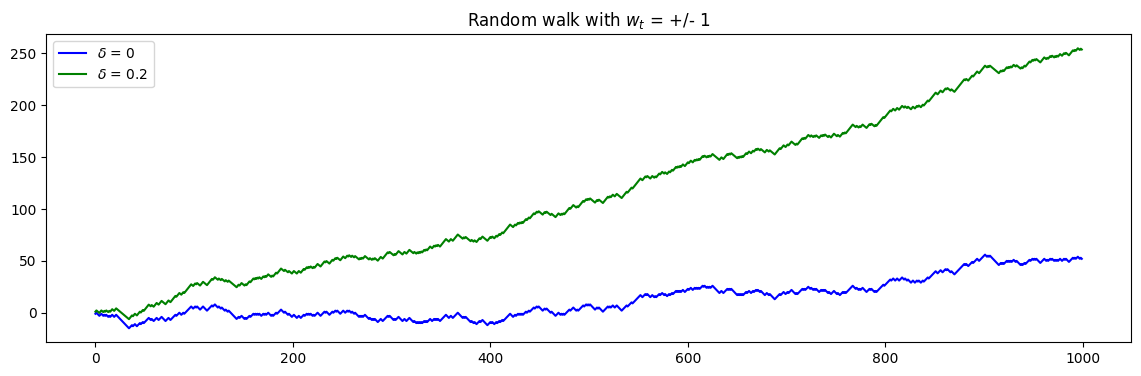

In [46]:
# Seed random number generator
random.seed(1)

# Create random walk series and random walk with drift series
random_walk = list()
random_walk_d = list()
random_walk.append(-1 if random.random() < 0.5 else 1)
random_walk_d.append(-1 if random.random() < 0.5 else 1)

for i in range(1, 1000):
    # Random walk
    movement = -1 if random.random() < 0.5 else 1
    value = random_walk[i - 1] + movement
    random_walk.append(value)

    # Random walk with drift
    movement_d = movement + 0.2
    value_d = random_walk_d[i - 1] + movement_d
    random_walk_d.append(value_d)


# Plot both the random walk series
plt.figure(figsize=(14, 4))
plt.plot(random_walk, color="blue", label="$\u03B4$ = 0")
plt.plot(random_walk_d, color="green", label="$\u03B4$ = 0.2")

plt.title("Random walk with $w_t$ = +/- 1")
plt.legend()
plt.show()



The autocorrelation function of the random walk model type typically shows a very slow decay.


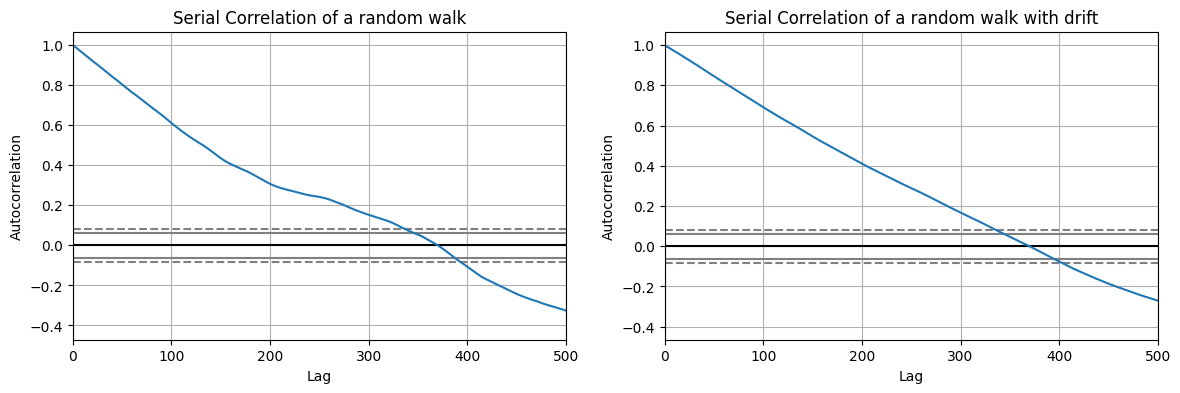

In [47]:
# Plotting the autocorrelation for both series for first 500 lags
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

autocorrelation_plot(random_walk, ax=ax[0])
ax[0].set_title("Serial Correlation of a random walk")
ax[0].set_xlim([0, 500])

autocorrelation_plot(random_walk_d, ax=ax[1])
ax[1].set_title("Serial Correlation of a random walk with drift")
ax[1].set_xlim([0, 500])

plt.show()

In the example, we see the expected trend, in this case across the first few hundred lag observations. The rise of the autocorrelation at very large lags is a finite-sample estimation effect. As the lag increases, the number of observation pairs used in the autocorrelation estimate (T−k) becomes very small, making the estimate highly unstable and causing random fluctuations in the tail of the correlogram.

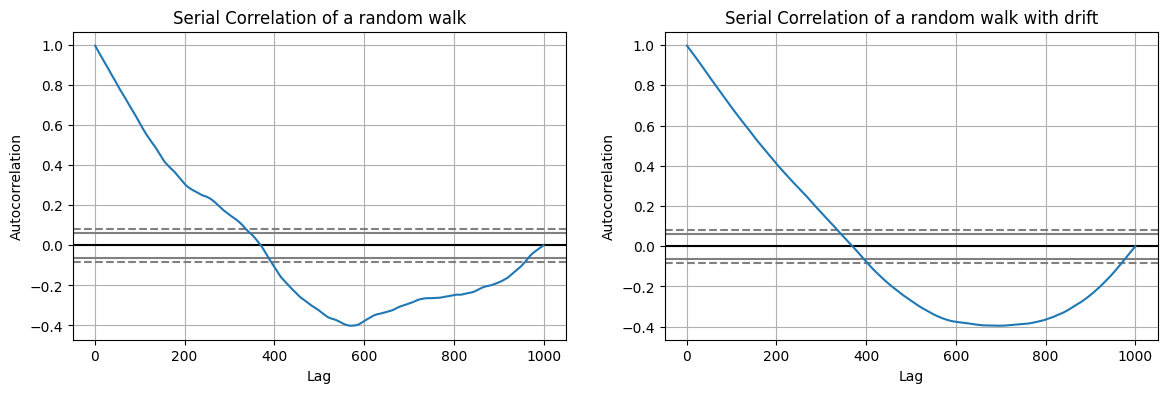

In [48]:
# Plotting the whole autocorrelation for both series
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

autocorrelation_plot(random_walk, ax=ax[0])
ax[0].set_title("Serial Correlation of a random walk")

autocorrelation_plot(random_walk_d, ax=ax[1])
ax[1].set_title("Serial Correlation of a random walk with drift")

plt.show()

## Summary:

* A random walk is a time series where the current value equals the previous value plus a random shock.
* A random walk without drift has no systematic trend, while a random walk with drift includes a constant expected change over time.
* The autocorrelation function of the random walk model type typically shows a very slow decay 

In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))